# About this Continuous Assessment

|                 |                                                  |
|-----------------|--------------------------------------------------|
| Delivery method | Canvas submission of this file after completion. |
| Deadline        | As specified on Canvas.                          |
| ILOs            | Differential kinematics using  `numpy`.          |

#### Macros (do not touch these)
$\providecommand{\myvec}[1]{{\mathbf{\boldsymbol{{#1}}}}}$
$\providecommand{\mymatrix}[1]{{\mathbf{\boldsymbol{{#1}}}}}$

# Allowed packages
Do not modify these. Do not add or remove packages.

In [3]:
%pip install numpy
%pip install numpy --break-system-packages
%pip install matplotlib
%pip install matplotlib --break-system-packages

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Allowed imports and definitions

Do not modify, add, or remove imports or definitions. Do not add imports anywhere else in this notebook. Do not add definitions outside the answer cells.

In [4]:
import numpy as np
from math import pi, sin, cos
import matplotlib.pyplot as plt

In [5]:
def damped_pseudo_inverse(A, damping = 0.01):
    """Calculates the damped pseudo inverse of A"""
    if damping == 0:
        raise Exception(f"Damping is {damping} but should be different from zero")

    return A.T @ np.linalg.inv(A @ A.T + (damping ** 2) * np.eye(A.shape[0]))

# Assigment description

Each cell is tagged for the assessment, so do not delete or otherwise tamper with the cells. The assigment is to add content to each of the Python cells as requested.

## Verify the spreadsheet

Your student ID will be used to assign you parameters. For each task, look into your row to see what you must implement.

## Converting a value from degrees to radians

Suppose that the `phi_deg` below is an angle in degrees. Its value in radians, `phi_rad`, should be calculated as follows.

**Do not** use lower precision approximations of $\pi$.

In [6]:
phi_deg = 45 # Value in degrees
phi_rad = phi_deg * pi / 180.0 # Value in radians
# Print is just to illustrate, it is not needed in answers.
print(f"The value {phi_deg} in degrees is {phi_rad} in radians.")

The value 45 in degrees is 0.7853981633974483 in radians.


## Task A

Consider the controller and robot described in Tutorial 5.

Assign a value for `eta_A`, bellow, such that the control input norm is always below 0.15 and the error is below 0.5 at 8 seconds.

In [17]:
eta_A: float = 0.5 # Only this value will be marked

- **Do not change the cell bellow containing the controller code. The original code will be used for marking.**
- The performance of the controller with the selected gain can be seen in the two graphs after the cell below.

xd = [0.3        0.2        1.04719755]


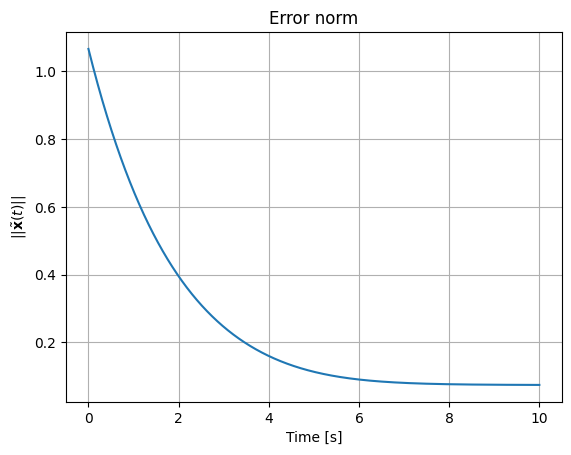

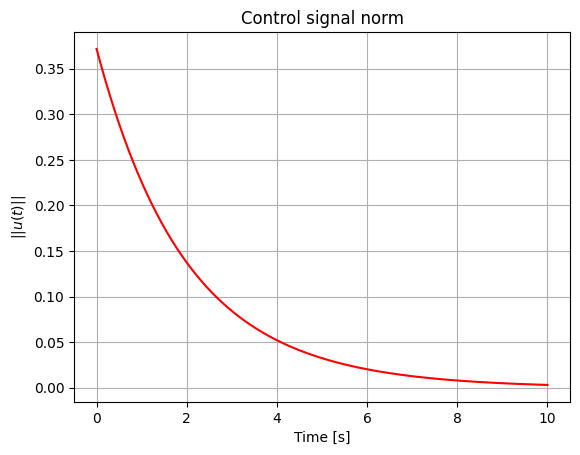

In [18]:
## ↓↓↓↓↓↓↓↓↓ Please don't change this code, it will not be used for marking ↓↓↓↓↓↓↓↓↓
T = 0.001 # Sampling time
q_0 = 0.0
q_1 = 0.0

def planar_robot_fkm(q):
    """
    q: The configuration space values in radians.
    returns the x, this, the current task space value where x = [p_x p_y phi_z]^T.
    """
    l_0 = 0.2 # The robot parameters. They don't change in time, so they are constant here.
    l_1 = 0.1

    q_0 = q[0] # Just to make it more readable.
    q_1 = q[1]

    p_x = l_0 * cos(q_0) + l_1 * cos(q_0 + q_1)
    p_y = l_0 * sin(q_0) + l_1 * sin(q_0 + q_1)
    phi_z = q_0 + q_1

    return np.array([p_x,
                     p_y,
                     phi_z])

def planar_robot_jacobian(q):
    """
    q: The configuration space values in radians.
    returns the 3x2 Jacobian mapping [q_0 q_1]^T to [px py phi_z]^T.
    """
    l_0 = 0.2 # The robot parameters. They don't change in time, so they are constant here.
    l_1 = 0.1

    q_0 = q[0] # Just to make it more readable.
    q_1 = q[1]

    J_1_1 = -l_0 * sin(q_0) - l_1 * sin(q_0 + q_1)
    J_1_2 = -l_1 * sin(q_0  + q_1)
    J_2_1 =  l_0 * cos(q_0) + l_1 * cos(q_0 + q_1)
    J_2_2 =  l_1 * cos(q_0 +  q_1)
    J_3_1 = 1
    J_3_2 = 1

    return np.array(
                [[J_1_1, J_1_2],
                 [J_2_1, J_2_2],
                 [J_3_1, J_3_2]]
        )

def get_error(x, xd):
    """In this case, we use the difference as the error.
    x: current task-space vector.
    xd: desired task-space vector.
    """
    return x - xd

q = np.array([q_0,
              q_1])

# A desired task-space value, defined by the problem at hand
xd = np.array([0.3,
               0.2,
               pi/3])
print(f"xd = {xd}")

# Define a stop criteria, in this case let's control for 10 seconds
t = 0 # Current time

# Lists to store the value of each control iteration
x_tilde_norm_list = []
t_list = []
u_norm_list = []

while t < 10:
    # Calculate task-space value, x
    x = planar_robot_fkm(q)
    # Calculate task-space error, x_tilde
    x_tilde = get_error(x, xd)
    # Get the Jacobian
    J = planar_robot_jacobian(q)
    # Invert the Jacobian, for example, with numpy's implementation of it
    J_inv = np.linalg.pinv(J)
    # Calculate the control action
    u = -eta_A * J_inv @ x_tilde

    ## Store values in the list so that we can print them later
    x_tilde_norm_list.append(np.linalg.norm(x_tilde))
    t_list.append(t)
    u_norm_list.append(np.linalg.norm(u))

    ## Variable updated for the next loop
    q = q + u * T # Update law using the sampling time
    t = t + T


plt.plot(t_list,x_tilde_norm_list)
plt.title('Error norm')
plt.xlabel("Time [s]")
plt.ylabel("$||\\tilde{ \\bf{x} } (t) ||$")
plt.grid()
plt.show()

plt.plot(t_list,u_norm_list, 'r')
plt.title('Control signal norm')
plt.xlabel("Time [s]")
plt.ylabel("$||u (t) ||$")
plt.grid()
plt.show()

## Task B

The forward kinematics of a manipulator is given by

$$ SE(2) \ni \mymatrix{H}^{C0}_{C3}(q_0,q_1,q_2) = \left[\begin{array}{ccc}
         c_{01} & -s_{01} & c_{0} + q_2c_{01}\\
         s_{01} &  c_{01} & s_{0} + q_2s_{01}\\
         0                 & 0                  & 1
        \end{array}\right].$$

The analytical Jacobian is

$$ \mymatrix{J}_C(q_0,q_1,q_2) = \left[\begin{array}{ccc}
         -s_{0} - q_2s_{01} & -q_2s_{01}& c_{01}\\
         c_{0} + q_2c_{01} & q_2c_{01} & s_{01}\\
         1                 & 1               & 0
        \end{array}\right].$$

The task-space can therefore be understood from inspection _Hint: it's the same as in Tutorial 5_.

Let

$$ \begin{aligned}
s_0    & \triangleq \sin{q_0} \\
s_{01} & \triangleq \sin{(q_0 + q_1)} \\
c_0    & \triangleq \cos{q_0} \\
c_{01} & \triangleq \cos{(q_0 + q_1)}
\end{aligned}$$

Correctly define `robot_fkm` and `robot_jacobian` so that the controller defined in the cell after it works correctly. Do not change the controller code, only the two specified functions in the cell below.

In [9]:
# Do not modify this(these) value(s). The original value(s) will be used for marking.
q_0 = 0.1 # Do not convert this value
q_1 = 0.3 # Do not convert this value
q_2 = 1 # Do not convert this value
q = np.array([q_0,
              q_1,
              q_2])
# Solve the task here.

def robot_fkm(q):
    q_0, q_1, q_2 = q

    s0 = np.sin(q_0)
    s01 = np.sin(q_0 + q_1)
    c0 = np.cos(q_0)
    c01 = np.cos(q_0 + q_1)

    p_x = c0 + q_2 * c01
    p_y = s0 + q_2 * s01
    phi_z = q_0 + q_1

    return np.array([p_x, p_y, phi_z])# <-- Replace this with your solution

def robot_jacobian(q):
    q_0, q_1, q_2 = q

    s0 = np.sin(q_0)
    s01 = np.sin(q_0 + q_1)
    c0 = np.cos(q_0)
    c01 = np.cos(q_0 + q_1)

    return np.array([
        [-s0 - q_2 * s01, -q_2 * s01, c01],
        [ c0 + q_2 * c01,  q_2 * c01, s01],
        [1.0, 1.0, 0.0]
    ]) # <-- Replace this with your solution


- The code below will show an error if `robot_fkm` and `robot_jacobian`, above, are not defined correctly.
- **Do not change the cell bellow containing the controller code. The original code will be used for marking.**

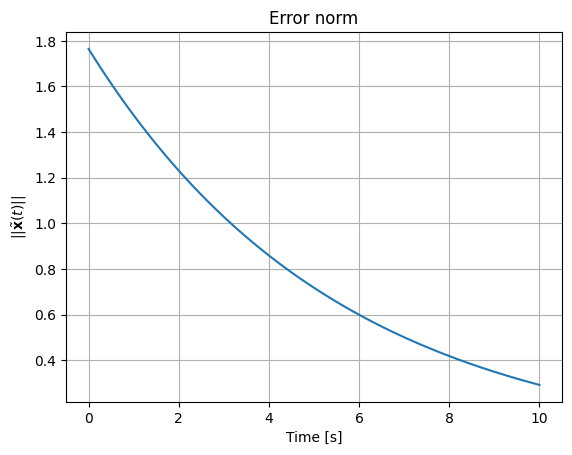

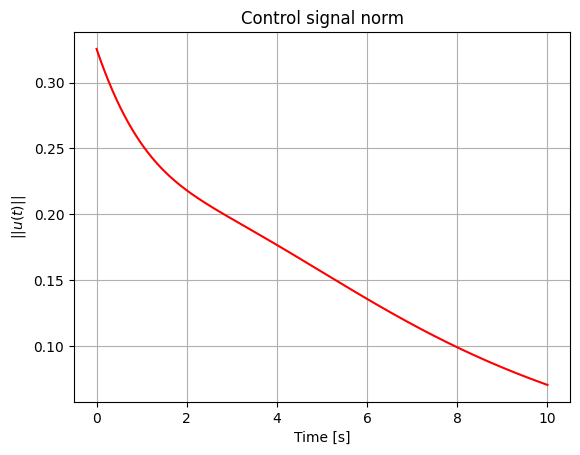

In [10]:
## ↓↓↓↓↓↓↓↓↓ Please don't change this code, it will not be used for marking ↓↓↓↓↓↓↓↓↓
T = 0.001 # Sampling time

def get_error(x, xd):
    """In this case, we use the difference as the error.
    x: current task-space vector.
    xd: desired task-space vector.
    """
    return x - xd

xd = np.array([0.3,
               0.2,
               pi/3])


t = 0

x_tilde_norm_list = []
t_list = []
u_norm_list = []

while t < 10:
    x = robot_fkm(q)
    if x is None: raise ValueError("You must add your code to `robot_fkm` so that it computes the robot FKM properly.")
    x_tilde = get_error(x, xd)
    x_tilde = get_error(x, xd)
    J = robot_jacobian(q)
    if J is None: raise ValueError("You must add your code to `robot_jacobian` so that it computes the robot Jacobian properly.")
    J_inv = np.linalg.pinv(J)
    u = -eta_A * J_inv @ x_tilde
    x_tilde_norm_list.append(np.linalg.norm(x_tilde))
    t_list.append(t)
    u_norm_list.append(np.linalg.norm(u))
    q = q + u * T
    t = t + T


plt.plot(t_list,x_tilde_norm_list)
plt.title('Error norm')
plt.xlabel("Time [s]")
plt.ylabel("$||\\tilde{ \\bf{x} } (t) ||$")
plt.grid()
plt.show()

plt.plot(t_list,u_norm_list, 'r')
plt.title('Control signal norm')
plt.xlabel("Time [s]")
plt.ylabel("$||u (t) ||$")
plt.grid()
plt.show()